Fifth Assignment: K-Nearest Neighbours


In [16]:
from google. colab import drive
drive. mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
df = pd.read_csv('/content/drive/MyDrive/ML_HW/wine.csv')
#print('Shape', df.shape)
print('\nColumns')
print(df.columns.tolist())
print("\nFirst five rows:")
display(df.head(5))



Columns
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

First five rows:


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [19]:
print(df.isnull().sum())
print(df.info())

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Non

In [20]:
# define y = target and  X = features using iloc
y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (178, 13), y shape: (178,)


In [21]:
#Shuffling and Splitting
indices = np.arange(len(X))
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(0.8 * len(X))
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

#Raw Split
x_train_raw, y_train = X[train_idx], y[train_idx]
x_test_raw, y_test = X[test_idx], y[test_idx]

#Standardization
X_mean = np.mean(x_train_raw, axis=0)
X_std = np.std(x_train_raw, axis=0)

#If X_std is 0, changing to 1 (no crashing)
X_std = np.where(X_std == 0, 1.0, X_std)

# Resizing the standartization
x_train = (x_train_raw - X_mean) / X_std
x_test = (x_test_raw - X_mean) / X_std

print("Train set:", x_train.shape)
print("Test set :", x_test.shape)
print ('\nStandartized x_train\n:', x_train[:3])


Train set: (142, 13)
Test set : (36, 13)

Standartized x_train
: [[ 0.76612803  0.64398607  0.71954557 -1.34107776  1.09664306  0.68800671
   1.05294003 -1.57265679  0.13694577  0.06866307 -0.02867826  1.05379706
   0.30695404]
 [ 1.46895477  1.45791715  0.28993602 -0.16908465  0.75303469  0.93723363
   0.66007152 -0.51850848 -0.56060302  0.13113545 -0.42879635  1.01087541
   1.0449264 ]
 [-0.10932281  0.39287968  1.2207567   0.49610062 -0.27779043 -1.23934814
  -1.56273716  1.34652313 -1.41127228 -0.15445261 -0.87337201 -0.44846073
  -0.4624214 ]]


In [22]:
#Task1.Euclidean distance
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))



In [23]:
#Task2 Distance Function (Sort distances)
#2.Find Neighbors and Sort
def get_neighbors(x_train, y_train, x_test_row, k):
    distances = []

    #Measuring distance
    for i in range(len(x_train)):
        dist = euclidean_distance(x_test_row, x_train[i])
        # We store a pair: (the distance, the wine's class)
        distances.append((dist, y_train[i]))

    # 2.Sorting
    distances.sort(key=lambda x: x[0])

    #Returning 'k'
    return distances[:k]

In [24]:
#Task3 Voting(Majority class)

def knn_predict(neighbors):


    neighbor_labels = [n[1] for n in neighbors]

    #Finding unique labels
    unique_labels, counts = np.unique(neighbor_labels, return_counts=True)

    #Finding the index of the label(class) with the votes_most_index
    votes_most_index = np.argmax(counts)


    return unique_labels[votes_most_index]



In [28]:
 def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [42]:
#Task 4 Experiments(Test with:k = [1 3 5 7])
exp_set = [1, 3, 5, 7]
accur_plot = []

for k in exp_set:

    predictions = []

    # Predict for set
    for row in x_test:
        neighbors = get_neighbors(x_train, y_train, row, k)
        pred = knn_predict(neighbors)
        predictions.append(pred)
        unique, counts = np.unique(predictions, return_counts=True)
    print(f"\nResults for every k={k}")
    for label, count in zip(unique, counts):
        print(f"Class {label} is a winner and occurs {count} times.")

    #accur_plot.append(accur)
    accur = accuracy_score(y_test, predictions)
    accur_plot.append(accur)
    print(f"Accuracy for k={k}: {accur * 100}%")






Results for every k=1
Class 1 is a winner and occurs 13 times.
Class 2 is a winner and occurs 12 times.
Class 3 is a winner and occurs 11 times.
Accuracy for k=1: 94.44444444444444%

Results for every k=3
Class 1 is a winner and occurs 13 times.
Class 2 is a winner and occurs 12 times.
Class 3 is a winner and occurs 11 times.
Accuracy for k=3: 94.44444444444444%

Results for every k=5
Class 1 is a winner and occurs 12 times.
Class 2 is a winner and occurs 13 times.
Class 3 is a winner and occurs 11 times.
Accuracy for k=5: 97.22222222222221%

Results for every k=7
Class 1 is a winner and occurs 12 times.
Class 2 is a winner and occurs 13 times.
Class 3 is a winner and occurs 11 times.
Accuracy for k=7: 97.22222222222221%


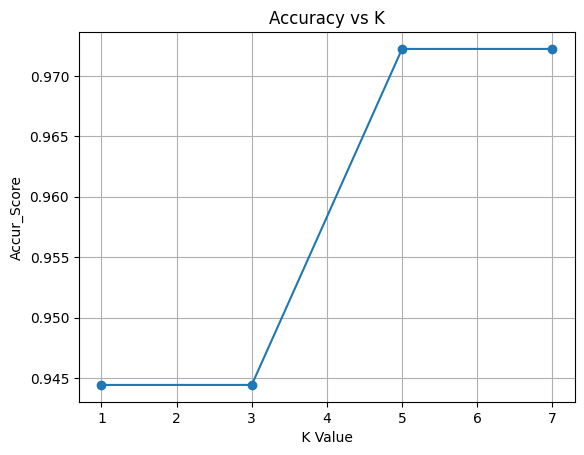

In [44]:
#Task5 Visualization(Plot accuracy vs k)
#accuracies.append(accur)

#Plot
plt.plot(exp_set, accur_plot, marker='o')
plt.title('Accuracy vs K')
plt.xlabel(' K Value ')
plt.ylabel('Accur_Score')
plt.grid(True)
plt.show()
